In [1]:
# =============================================================================
# 셀 1: 03_Sub_Regime — 설계 + 환경 설정
# =============================================================================
# 목적: regime_v4(Bull/Bear/Neutral)의 "확신도(confidence)"를 계산하여
#       06_TheForge 팩터 가중치 최적화에 활용할 sub-regime 생성
#
# ─────────────────────────────────────────────────────────────────────
# [배경]
# ─────────────────────────────────────────────────────────────────────
#
#   regime_v4는 S&P500 가격 기반 3레짐 (Bull/Bear/Neutral)
#   문제: 같은 Bull이라도 "모든 종목이 같이 오르는 Bull"과
#          "일부만 오르는 Bull"은 팩터 유효성이 완전히 다름
#
#   해결: 거시변수 + 시장 구조 지표로 "확신도"를 부여
#         → High Confidence Bull vs Low Confidence Bull
#         → 06_TheForge에서 확신도별 팩터 가중치 최적화
#
# ─────────────────────────────────────────────────────────────────────
# [이미 있는 것 — regime_v4.parquet]
# ─────────────────────────────────────────────────────────────────────
#
#   regime_v4.parquet에 이미 포함된 거시 필터 5개:
#     1. baa_rising:      BAA 스프레드 3M 변화 > 0     (신용 위험)
#     2. unrate_rising:   실업률 3M 변화 > 0            (고용 악화)
#     3. yield_curve_flat: 10Y-2Y < 0.5%               (수익률 곡선)
#     4. vix_high:        VIX > 20                     (시장 공포)
#     5. t10y3m_inv:      10Y-3M < 0                   (경기침체 선행)
#
#   macro_bear_count (0~5): Bear 시그널 ON 개수
#   macro_confirm: none/weak/moderate/strong
#
#   ⚠ 문제: 이건 Bear 감지 전용으로만 설계됨
#           Bull/Neutral 확신도로는 아직 안 쓰임
#
# ─────────────────────────────────────────────────────────────────────
# [새로 만들 것]
# ─────────────────────────────────────────────────────────────────────
#
#   A. W-12: Cross-Sectional Dispersion (종목간 수익률 분산)
#      - ret_1m의 횡단면 표준편차 → 월간 시계열
#      - 높으면 = 종목선별 먹히는 시기 (팩터 ON)
#      - 낮으면 = 베타만 먹히는 시기 (팩터 OFF)
#      - 데이터: ret_1m (이미 있음, 추가 수집 불필요)
#
#   B. 거시변수 Bull/Bear/Neutral 양방향 확장
#      - 기존: Bear 감지 전용 (macro_bear_count)
#      - 신규: 각 변수마다 Bull/Neutral/Bear 3방향 신호 생성
#      - 데이터: regime_v4.parquet 내 거시변수 재활용
#               (추가 FRED 수집 불필요 — 이미 들어가 있음)
#
#   C. 최종 confidence score
#      - v4 레짐과 거시변수 동의율 (0~1)
#      - W-12 팩터 유효성 스위치 (ON/OFF)
#      - 둘을 결합한 sub_regime 라벨:
#        ex) Bull_High, Bull_Low, Bear_High, Bear_Low, Neutral_High, Neutral_Low
#
# ─────────────────────────────────────────────────────────────────────
# [셀 구조 계획]
# ─────────────────────────────────────────────────────────────────────
#
#   셀 1: 설계 + 환경 설정 (이 셀)
#   셀 2: 데이터 로드 (regime_v4, ret_1m, px_wide)
#   셀 3: W-12 횡단면 분산 계산 + 시각화
#   셀 4: W-12 × 레짐 교차 분석 (분산 높을 때/낮을 때 팩터 성과 차이)
#   셀 5: 거시변수 양방향 확장 (Bull/Neutral/Bear 3방향 신호)
#   셀 6: confidence score 설계 + 계산
#   셀 7: sub_regime별 과거 팩터 성과 분해 (06_TheForge 데이터 필요)
#   셀 8: sub_regime.parquet 저장 + 최종 요약
#
# ─────────────────────────────────────────────────────────────────────
# [산출물]
# ─────────────────────────────────────────────────────────────────────
#
#   data/interim/sub_regime.parquet
#     index: date (월말)
#     컬럼:
#       regime          : Bull / Neutral / Bear (v4 그대로)
#       bear_phase      : declining / recovering
#       w12_dispersion  : 횡단면 분산 (연율화)
#       w12_high        : 분산 > 중위수 (bool)
#       macro_bull_count: Bull 방향 거시 시그널 수 (0~5)
#       macro_bear_count: Bear 방향 거시 시그널 수 (0~5) (기존)
#       confidence      : v4 레짐과 거시변수 동의율 (0~1)
#       sub_regime      : Bull_High / Bull_Low / Bear_High / ...
#
#   → 06_TheForge_v2에서 sub_regime별 가중치 최적화에 사용
#
# ─────────────────────────────────────────────────────────────────────
# [핵심 원칙]
# ─────────────────────────────────────────────────────────────────────
#
#   1. 미래 정보 절대 금지
#      - 모든 지표는 해당 월말 시점에 구할 수 있는 것만 사용
#      - W-12: t월 분산은 t월 수익률로 계산 → t+1월 리밸런싱에 사용
#      - 거시변수: t월말 기준 값 → t+1월 리밸런싱에 사용
#
#   2. 단순하게
#      - confidence 임계값은 최대 2단계 (High/Low)
#      - 과적합 방지: 3단계 이상 나누지 않음 (표본 부족)
#
#   3. 효과 없으면 폐기
#      - sub_regime이 성과를 개선하지 못하면 v4 그대로 유지
#      - "있어봤자 해 없는" 변수는 넣지 않음
#
# =============================================================================

import os, warnings, logging
from pathlib import Path
from dotenv import load_dotenv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s",
                    datefmt="%H:%M:%S")
logger = logging.getLogger(__name__)

# ── SSOT 경로 ──
load_dotenv(Path("C:/QP2/.env"))
QP2_ROOT    = Path(os.getenv("QP2_ROOT", "C:/QP2"))
DATA_DIR    = QP2_ROOT / "data"
RAW_DIR     = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
META_DIR    = DATA_DIR / "meta"

# ── 파라미터 ──
TOP_N       = 30
COST_BP     = 20
REGIME_COL  = "regime"

# W-12 파라미터
W12_LOOKBACK = 1          # 횡단면 분산 계산 기간 (월, 1=당월)
W12_THRESHOLD = "median"  # High/Low 분류 기준

# ── 공용 유틸 ──
def winsorize(s, lower=0.01, upper=0.99):
    lo, hi = s.quantile(lower), s.quantile(upper)
    return s.clip(lo, hi)

def zscore_by_date(df, col):
    g = df.groupby("date")[col]
    return (df[col] - g.transform("mean")) / g.transform("std")

def calc_perf(ret_series, name=""):
    cum = (1 + ret_series).cumprod()
    total = cum.iloc[-1]
    n_years = len(ret_series) / 12
    cagr = total ** (1 / n_years) - 1 if n_years > 0 else 0
    sharpe = ret_series.mean() / ret_series.std() * np.sqrt(12) if ret_series.std() > 0 else 0
    dd = cum / cum.cummax() - 1
    maxdd = dd.min()
    return {"name": name, "CAGR": cagr, "Sharpe": sharpe, "MaxDD": maxdd, "N": len(ret_series)}

def calc_tstat(port_ret, bm_ret):
    diff = port_ret - bm_ret
    n = len(diff.dropna())
    if n < 6 or diff.std() == 0:
        return 0.0
    return diff.mean() / diff.std() * np.sqrt(n)

# ── 차트 설정 ──
rcParams["figure.figsize"] = (14, 6)
rcParams["axes.grid"] = True
rcParams["grid.alpha"] = 0.3

logger.info("셀 1 완료 — 03_Sub_Regime 환경 설정")
logger.info(f"  QP2_ROOT: {QP2_ROOT}")
logger.info(f"  W12_THRESHOLD: {W12_THRESHOLD}")

10:17:36 [INFO] 셀 1 완료 — 03_Sub_Regime 환경 설정
10:17:36 [INFO]   QP2_ROOT: C:\QP2
10:17:36 [INFO]   W12_THRESHOLD: median


In [2]:
# =============================================================================
# 셀 2: 데이터 로드
# =============================================================================
# 목적: regime_v4, 월간 수익률, 주가 로드
# 산출물: regime_v4, ret_1m_wide, ew_ret, px_m
# =============================================================================

# ── regime_v4 로드 ──
regime_v4 = pd.read_parquet(INTERIM_DIR / "regime_v4.parquet")
regime_v4.index = pd.to_datetime(regime_v4.index)
logger.info(f"regime_v4: {regime_v4.shape}, {regime_v4.index[0].date()} ~ {regime_v4.index[-1].date()}")
logger.info(f"  컬럼: {list(regime_v4.columns)}")
logger.info(f"  레짐 분포:\n{regime_v4['regime'].value_counts().to_string()}")

# ── 거시변수 컬럼 확인 ──
macro_cols = [c for c in regime_v4.columns if c.startswith("macro") or c in 
              ["baa_rising", "unrate_rising", "yield_curve_flat", "vix_high", "t10y3m_inv"]]
logger.info(f"  거시변수 컬럼: {macro_cols}")

# ── 주가 / 월간 수익률 ──
px_wide = pd.read_parquet(INTERIM_DIR / "yahoo_adjclose_wide.parquet")
px_wide.index = pd.to_datetime(px_wide.index)

px_m = px_wide.resample("ME").last()
ret_1m_wide = px_m.pct_change()

# NaN 과다 종목 제거 (50% 이상 유효)
valid_tickers = ret_1m_wide.columns[ret_1m_wide.notna().sum() > len(ret_1m_wide) * 0.5]
ret_1m_wide = ret_1m_wide[valid_tickers]
px_m = px_m[valid_tickers]

# EW 벤치마크
ew_ret = ret_1m_wide.mean(axis=1)

# 백테스트 기간 필터 (2013-06 이후)
START_DATE = "2013-06-30"
ret_1m_wide = ret_1m_wide[ret_1m_wide.index >= START_DATE]
ew_ret = ew_ret[ew_ret.index >= START_DATE]
px_m = px_m[px_m.index >= START_DATE]

logger.info(f"ret_1m_wide: {ret_1m_wide.shape} ({len(valid_tickers)} tickers)")
logger.info(f"백테스트 기간: {ret_1m_wide.index[0].date()} ~ {ret_1m_wide.index[-1].date()}")
logger.info(f"셀 2 완료")

10:18:05 [INFO] regime_v4: (765, 9), 1962-06-30 ~ 2026-02-28
10:18:05 [INFO]   컬럼: ['price', 'ma', 'price_vs_ma', 'mom', 'drawdown', 'regime', 'bear_phase', 'macro_bear_count', 'macro_confirm']
10:18:05 [INFO]   레짐 분포:
regime
Bull       551
Bear       170
Neutral     44
10:18:05 [INFO]   거시변수 컬럼: ['macro_bear_count', 'macro_confirm']
10:18:06 [INFO] ret_1m_wide: (153, 277) (277 tickers)
10:18:06 [INFO] 백테스트 기간: 2013-06-30 ~ 2026-02-28
10:18:06 [INFO] 셀 2 완료


10:20:01 [INFO] W-12 횡단면 분산:
10:20:01 [INFO]   월간 std: mean=0.0641, median=0.0616
10:20:01 [INFO]   연율화:   mean=22.21%, median=21.35%
10:20:01 [INFO]   임계값 (median): 0.0616
10:20:01 [INFO]   High: 76M, Low: 77M



W-12 by Regime
  Bull    : mean=0.0613, median=0.0586, High=49/117
  Bear    : mean=0.0753, median=0.0682, High=19/23
  Neutral : mean=0.0696, median=0.0706, High=8/13


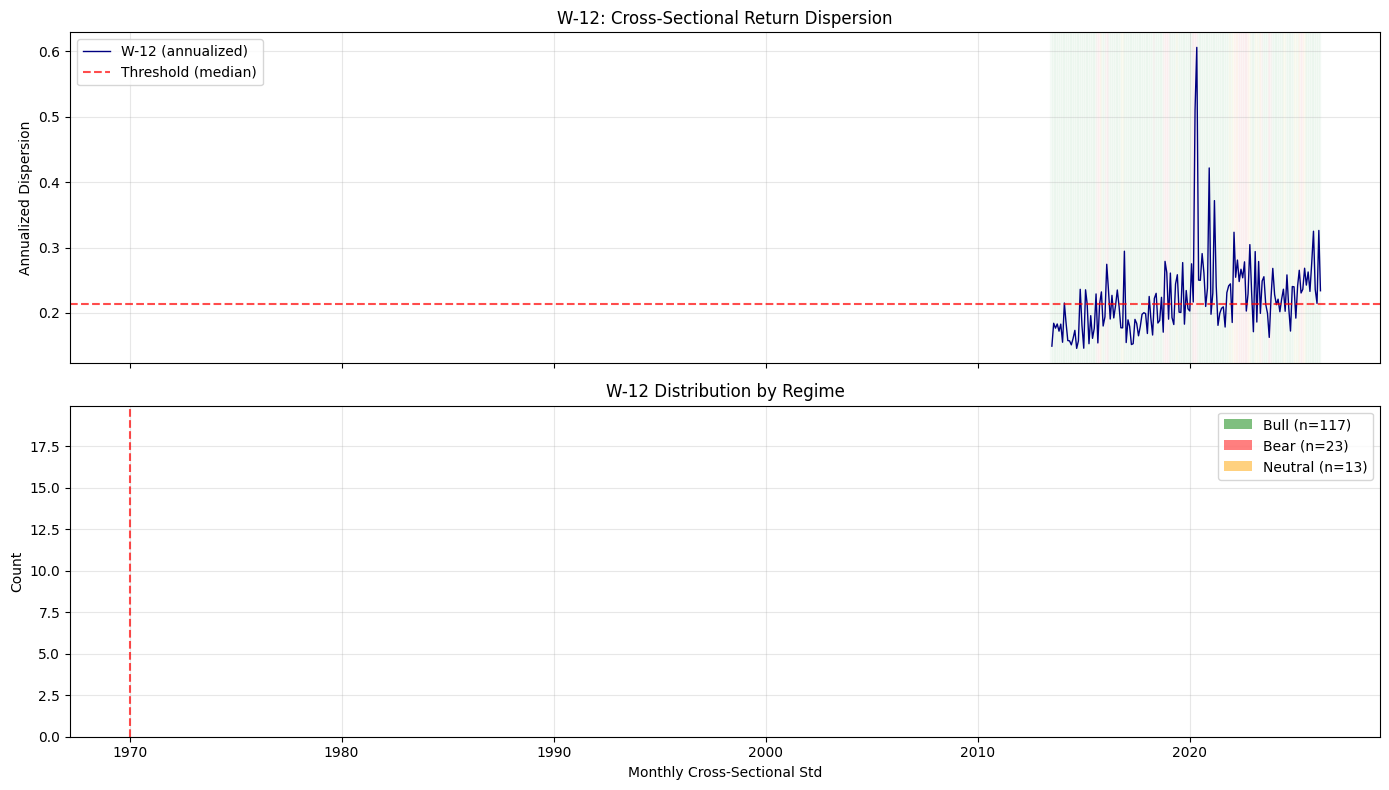

10:20:02 [INFO] 셀 3 완료 — W-12 계산 + 시각화


In [4]:
# =============================================================================
# 셀 3: W-12 횡단면 분산 (Cross-Sectional Dispersion)
# =============================================================================
# 목적: 매월 종목간 수익률의 횡단면 표준편차 계산
#       높으면 = 종목선별 먹히는 시기, 낮으면 = 베타만 먹히는 시기
# 산출물: w12 (월간 시계열), w12_high (bool)
# =============================================================================

# ── 1. 횡단면 분산 계산 ──
# 매월: 503종목 수익률의 std (= 종목간 얼마나 흩어져 있나)
w12 = ret_1m_wide.std(axis=1)               # 월간 횡단면 std
w12_ann = w12 * np.sqrt(12)                  # 연율화
w12.name = "w12_dispersion"
w12_ann.name = "w12_ann"

logger.info(f"W-12 횡단면 분산:")
logger.info(f"  월간 std: mean={w12.mean():.4f}, median={w12.median():.4f}")
logger.info(f"  연율화:   mean={w12_ann.mean():.2%}, median={w12_ann.median():.2%}")

# ── 2. High/Low 분류 ──
if W12_THRESHOLD == "median":
    threshold = w12.median()
else:
    threshold = w12.quantile(0.7)

w12_high = w12 > threshold
logger.info(f"  임계값 ({W12_THRESHOLD}): {threshold:.4f}")
logger.info(f"  High: {w12_high.sum()}M, Low: {(~w12_high).sum()}M")

# ── 3. 레짐별 W-12 분포 ──
# regime_v4를 백테스트 기간에 맞춰 매핑
regime_bt = regime_v4.loc[regime_v4.index >= START_DATE, "regime"]
# 인덱스 맞추기 (월말)
regime_bt.index = regime_bt.index + pd.offsets.MonthEnd(0)
common_idx = w12.index.intersection(regime_bt.index)

print("\n" + "=" * 60)
print("W-12 by Regime")
print("=" * 60)
for reg in ["Bull", "Bear", "Neutral"]:
    mask = regime_bt.loc[common_idx] == reg
    vals = w12.loc[common_idx][mask]
    if len(vals) > 0:
        print(f"  {reg:8s}: mean={vals.mean():.4f}, median={vals.median():.4f}, "
              f"High={( vals > threshold).sum()}/{len(vals)}")

# ── 4. 시각화 ──
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# 상단: W-12 시계열 + 레짐 배경
ax = axes[0]
ax.plot(w12_ann.index, w12_ann.values, color="navy", linewidth=1, label="W-12 (annualized)")
ax.axhline(threshold * np.sqrt(12), color="red", linestyle="--", alpha=0.7, label=f"Threshold ({W12_THRESHOLD})")

# 레짐 배경색
regime_colors = {"Bull": "#d4edda", "Bear": "#f8d7da", "Neutral": "#fff3cd"}
for dt in common_idx:
    reg = regime_bt.loc[dt]
    ax.axvspan(dt - pd.offsets.MonthEnd(1), dt, alpha=0.15, color=regime_colors.get(reg, "white"))

ax.set_ylabel("Annualized Dispersion")
ax.set_title("W-12: Cross-Sectional Return Dispersion")
ax.legend()

# 하단: 히스토그램 by 레짐
ax2 = axes[1]
for reg, color in [("Bull", "green"), ("Bear", "red"), ("Neutral", "orange")]:
    mask = regime_bt.loc[common_idx] == reg
    vals = w12.loc[common_idx][mask]
    if len(vals) > 0:
        ax2.hist(vals, bins=20, alpha=0.5, color=color, label=f"{reg} (n={len(vals)})")

ax2.axvline(threshold, color="red", linestyle="--", alpha=0.7)
ax2.set_xlabel("Monthly Cross-Sectional Std")
ax2.set_ylabel("Count")
ax2.set_title("W-12 Distribution by Regime")
ax2.legend()

plt.tight_layout()
plt.show()

logger.info("셀 3 완료 — W-12 계산 + 시각화")
# 그래프 아쉽게 나오긴했는데 사소함 ㅇㅇ

레짐 × W-12 교차표 (개월 수)
         Low  High  Total
regime                   
Bear       4    19     23
Bull      68    49    117
Neutral    5     8     13
All       77    76    153

EW 수익률 by Regime × W-12
 Regime W-12  N Ann_Ret Ann_Vol Sharpe Mean_Disp
   Bull High 49  36.08%  12.16%   2.97    0.0734
   Bull  Low 68  19.45%   8.80%   2.21    0.0526
   Bear High 19 -29.32%  23.22%  -1.26    0.0804
   Bear  Low  4 -64.70%   8.49%  -7.62    0.0513
Neutral High  8  21.21%  18.94%   1.12    0.0786
Neutral  Low  5 -27.47%  10.97%  -2.50    0.0553

핵심: Bull_High vs Bull_Low 비교
  Bull_High: 49M, CAGR=41.72%, Sharpe=2.97
  Bull_Low:  68M, CAGR=20.83%, Sharpe=2.21
  차이:      CAGR=20.89%p, Sharpe=0.76


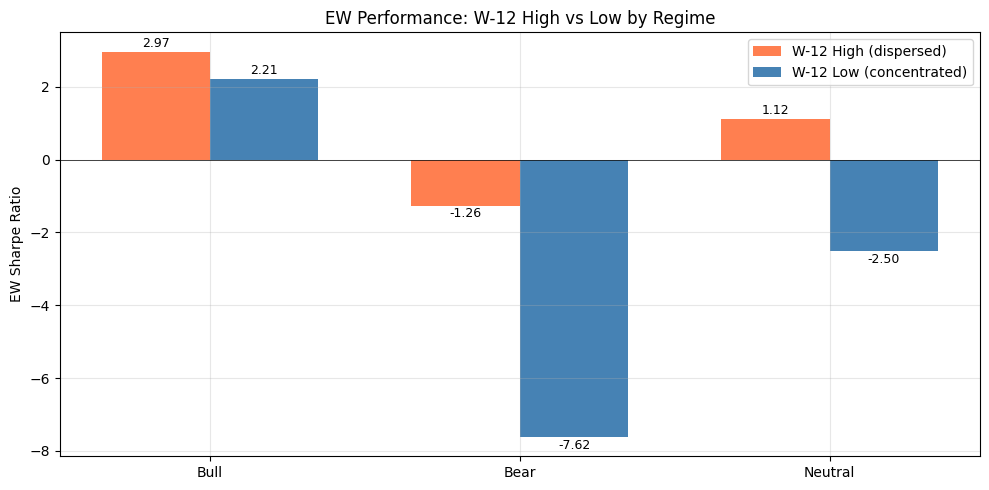

10:20:13 [INFO] 셀 4 완료 — W-12 × 레짐 교차 분석


In [5]:
# =============================================================================
# 셀 4: W-12 × 레짐 교차 분석
# =============================================================================
# 목적: W-12 High/Low일 때 EW 수익률 + 종목선별 효과가 다른지 검증
#       "분산 높으면 팩터 먹힌다"는 가설의 1차 검증
# 산출물: 레짐 × W-12 교차표, EW 성과 비교
# =============================================================================

# ── 1. 교차표: regime × W-12 ──
sub_df = pd.DataFrame({
    "regime": regime_bt.loc[common_idx],
    "w12": w12.loc[common_idx],
    "w12_high": w12_high.loc[common_idx],
    "ew_ret": ew_ret.loc[common_idx],
}, index=common_idx)

print("=" * 70)
print("레짐 × W-12 교차표 (개월 수)")
print("=" * 70)
ct = pd.crosstab(sub_df["regime"], sub_df["w12_high"], margins=True)
ct.columns = ["Low", "High", "Total"]
print(ct)

# ── 2. 레짐 × W-12별 EW 수익률 비교 ──
print("\n" + "=" * 70)
print("EW 수익률 by Regime × W-12")
print("=" * 70)

results = []
for reg in ["Bull", "Bear", "Neutral"]:
    for hi in [True, False]:
        mask = (sub_df["regime"] == reg) & (sub_df["w12_high"] == hi)
        ew = sub_df.loc[mask, "ew_ret"]
        if len(ew) < 3:
            continue
        ann = ew.mean() * 12
        vol = ew.std() * np.sqrt(12)
        sharpe = ann / vol if vol > 0 else 0
        label = "High" if hi else "Low"
        results.append({
            "Regime": reg,
            "W-12": label,
            "N": len(ew),
            "Ann_Ret": f"{ann:.2%}",
            "Ann_Vol": f"{vol:.2%}",
            "Sharpe": f"{sharpe:.2f}",
            "Mean_Disp": f"{sub_df.loc[mask, 'w12'].mean():.4f}",
        })

res_df = pd.DataFrame(results)
print(res_df.to_string(index=False))

# ── 3. 핵심 질문: Bull 내 High vs Low ──
print("\n" + "=" * 70)
print("핵심: Bull_High vs Bull_Low 비교")
print("=" * 70)

bull_high = sub_df[(sub_df["regime"] == "Bull") & (sub_df["w12_high"] == True)]["ew_ret"]
bull_low  = sub_df[(sub_df["regime"] == "Bull") & (sub_df["w12_high"] == False)]["ew_ret"]

if len(bull_high) >= 6 and len(bull_low) >= 6:
    perf_h = calc_perf(bull_high, "Bull_High")
    perf_l = calc_perf(bull_low, "Bull_Low")
    
    print(f"  Bull_High: {perf_h['N']}M, CAGR={perf_h['CAGR']:.2%}, Sharpe={perf_h['Sharpe']:.2f}")
    print(f"  Bull_Low:  {perf_l['N']}M, CAGR={perf_l['CAGR']:.2%}, Sharpe={perf_l['Sharpe']:.2f}")
    print(f"  차이:      CAGR={perf_h['CAGR'] - perf_l['CAGR']:.2%}p, "
          f"Sharpe={perf_h['Sharpe'] - perf_l['Sharpe']:.2f}")

# ── 4. 시각화: 레짐 × W-12 Sharpe 비교 ──
fig, ax = plt.subplots(figsize=(10, 5))

regimes = ["Bull", "Bear", "Neutral"]
x = np.arange(len(regimes))
width = 0.35

sharpe_high = []
sharpe_low = []

for reg in regimes:
    for hi, lst in [(True, sharpe_high), (False, sharpe_low)]:
        mask = (sub_df["regime"] == reg) & (sub_df["w12_high"] == hi)
        ew = sub_df.loc[mask, "ew_ret"]
        if len(ew) >= 3:
            s = ew.mean() / ew.std() * np.sqrt(12)
            lst.append(s)
        else:
            lst.append(0)

bars1 = ax.bar(x - width/2, sharpe_high, width, label="W-12 High (dispersed)", color="coral")
bars2 = ax.bar(x + width/2, sharpe_low, width, label="W-12 Low (concentrated)", color="steelblue")

ax.set_xticks(x)
ax.set_xticklabels(regimes)
ax.set_ylabel("EW Sharpe Ratio")
ax.set_title("EW Performance: W-12 High vs Low by Regime")
ax.legend()
ax.axhline(0, color="black", linewidth=0.5)

# 값 표시
for bar in bars1 + bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.05 * np.sign(h),
            f"{h:.2f}", ha="center", va="bottom" if h >= 0 else "top", fontsize=9)

plt.tight_layout()
plt.show()

logger.info("셀 4 완료 — W-12 × 레짐 교차 분석")

In [6]:
# =============================================================================
# 셀 5: 거시변수 양방향 확장
# =============================================================================
# 목적: 기존 Bear 전용 거시 필터를 Bull/Neutral/Bear 3방향으로 확장
#       각 변수마다 Bull/Neutral/Bear 신호를 생성
# 산출물: macro_signals (DataFrame), macro_bull_count, macro_bear_count
# =============================================================================

# ── 1. regime_v4에서 거시변수 컬럼 확인 ──
print("=" * 70)
print("regime_v4 컬럼 전체 확인")
print("=" * 70)
print(regime_v4.columns.tolist())
print()

# 백테스트 기간 필터
rv4 = regime_v4.loc[regime_v4.index >= START_DATE].copy()
rv4.index = rv4.index + pd.offsets.MonthEnd(0)

# 기존 거시변수 컬럼 존재 여부 확인
macro_binary_cols = ["baa_rising", "unrate_rising", "yield_curve_flat", "vix_high", "t10y3m_inv"]
found = [c for c in macro_binary_cols if c in rv4.columns]
missing = [c for c in macro_binary_cols if c not in rv4.columns]

print(f"발견된 거시변수: {found}")
print(f"미발견: {missing}")

if found:
    print("\n기존 거시변수 샘플 (최근 12개월):")
    print(rv4[found].tail(12).to_string())
    print(f"\n기존 macro_bear_count 분포:")
    if "macro_bear_count" in rv4.columns:
        print(rv4["macro_bear_count"].value_counts().sort_index().to_string())

# ── 2. 거시변수 양방향 신호 설계 ──
# 기존: 각 변수가 True/False (Bear 위험 ON/OFF)
# 신규: 각 변수에 대해 Bull/Neutral/Bear 3방향 판정
#
# 설계 원칙:
#   - Bear 임계값 = 기존 그대로 (이미 검증됨)
#   - Bull 임계값 = Bear의 반대 극단
#   - Neutral = 그 사이
#
# ┌──────────────────┬──────────────┬──────────────┬──────────────┐
# │ 변수             │ Bull         │ Neutral      │ Bear         │
# ├──────────────────┼──────────────┼──────────────┼──────────────┤
# │ baa_rising       │ 3M변화 < -0.1│ -0.1 ~ 0     │ > 0 (기존)   │
# │ unrate_rising    │ 3M변화 < -0.1│ -0.1 ~ 0     │ > 0 (기존)   │
# │ yield_curve_flat │ 10Y-2Y > 1.5%│ 0.5% ~ 1.5%  │ < 0.5%(기존) │
# │ vix_high         │ VIX < 15     │ 15 ~ 20      │ > 20 (기존)  │
# │ t10y3m_inv       │ 10Y-3M > 1.5%│ 0 ~ 1.5%     │ < 0 (기존)   │
# └──────────────────┴──────────────┴──────────────┴──────────────┘
#
# ⚠ 문제: regime_v4에 원시값(BAA수준, VIX수준)이 있는지 확인 필요
#         없으면 binary 컬럼만으로는 Bull 방향 판정 불가 → FRED 재수집

# ── 3. 원시 거시 데이터 확인 ──
# macro_indicators.parquet에서 원시값 로드 시도
macro_path = INTERIM_DIR / "macro_indicators.parquet"
if macro_path.exists():
    macro_raw = pd.read_parquet(macro_path)
    macro_raw.index = pd.to_datetime(macro_raw.index)
    print("\n" + "=" * 70)
    print("macro_indicators.parquet 로드 성공")
    print("=" * 70)
    print(f"  Shape: {macro_raw.shape}")
    print(f"  기간: {macro_raw.index[0].date()} ~ {macro_raw.index[-1].date()}")
    print(f"  컬럼: {list(macro_raw.columns)}")
    print(f"\n  최근 6개월:")
    print(macro_raw.tail(6).to_string())
else:
    print(f"\n⚠ {macro_path} 파일 없음 — FRED 재수집 필요할 수 있음")
    macro_raw = None

# market_regime_indicators도 확인 (VIX 등)
mkt_path = INTERIM_DIR / "market_regime_indicators.parquet"
if mkt_path.exists():
    mkt_raw = pd.read_parquet(mkt_path)
    mkt_raw.index = pd.to_datetime(mkt_raw.index)
    print(f"\nmarket_regime_indicators.parquet:")
    print(f"  Shape: {mkt_raw.shape}")
    print(f"  컬럼: {list(mkt_raw.columns)}")
else:
    print(f"\n⚠ {mkt_path} 파일 없음")
    mkt_raw = None

logger.info("셀 5 완료 — 거시변수 현황 확인")
logger.info("  다음 셀에서 원시값 기반 3방향 신호 생성")

10:22:58 [INFO] 셀 5 완료 — 거시변수 현황 확인
10:22:58 [INFO]   다음 셀에서 원시값 기반 3방향 신호 생성


regime_v4 컬럼 전체 확인
['price', 'ma', 'price_vs_ma', 'mom', 'drawdown', 'regime', 'bear_phase', 'macro_bear_count', 'macro_confirm']

발견된 거시변수: []
미발견: ['baa_rising', 'unrate_rising', 'yield_curve_flat', 'vix_high', 't10y3m_inv']

macro_indicators.parquet 로드 성공
  Shape: (314, 7)
  기간: 2000-01-31 ~ 2026-02-28
  컬럼: ['UNRATE', 'T10Y2Y', 'T10Y3M', 'BAMLH0A0HYM2', 'VIXCLS', 'FEDFUNDS', 'CPIAUCSL']

  최근 6개월:
            UNRATE  T10Y2Y  T10Y3M  BAMLH0A0HYM2  VIXCLS  FEDFUNDS  CPIAUCSL
2025-09-30     4.4    0.56    0.14          2.80   16.28      4.22   324.368
2025-10-31     NaN    0.51    0.22          2.94   17.44      4.09       NaN
2025-11-30     4.5    0.55    0.14          2.92   16.35      3.88   325.031
2025-12-31     4.4    0.71    0.51          2.81   14.95      3.72   326.030
2026-01-31     NaN    0.74    0.59          2.88   17.44      3.64       NaN
2026-02-28     NaN    0.71    0.47          2.84   17.36       NaN       NaN

market_regime_indicators.parquet:
  Shape: (769, 18)
  

In [9]:
print(macro_raw.isna().sum())
print(macro_raw.isna().sum() / len(macro_raw) * 100)  # NaN 비율

UNRATE          3
T10Y2Y          0
T10Y3M          0
BAMLH0A0HYM2    0
VIXCLS          0
FEDFUNDS        1
CPIAUCSL        3
dtype: int64
UNRATE          0.955414
T10Y2Y          0.000000
T10Y3M          0.000000
BAMLH0A0HYM2    0.000000
VIXCLS          0.000000
FEDFUNDS        0.318471
CPIAUCSL        0.955414
dtype: float64


거시변수 3방향 신호 분포 (전체 기간)
  t10y2y_sig     : Bear(-1)= 25, Neutral(0)=106, Bull(+1)= 22
  t10y3m_sig     : Bear(-1)= 38, Neutral(0)= 69, Bull(+1)= 46
  vix_sig        : Bear(-1)= 20, Neutral(0)= 76, Bull(+1)= 57
  baa_sig        : Bear(-1)= 35, Neutral(0)= 66, Bull(+1)= 52
  unrate_sig     : Bear(-1)= 12, Neutral(0)= 88, Bull(+1)= 53

Confidence 분포 by Regime
  Bull    : mean=0.36, median=0.40, min=0.00, max=1.00
  Bear    : mean=0.40, median=0.40, min=0.00, max=0.80
  Neutral : mean=0.58, median=0.60, min=0.40, max=1.00

Sub-Regime 분포
sub_regime
Bear_High        7
Bear_Low        16
Bull_High       28
Bull_Low        89
Neutral_High     7
Neutral_Low      6


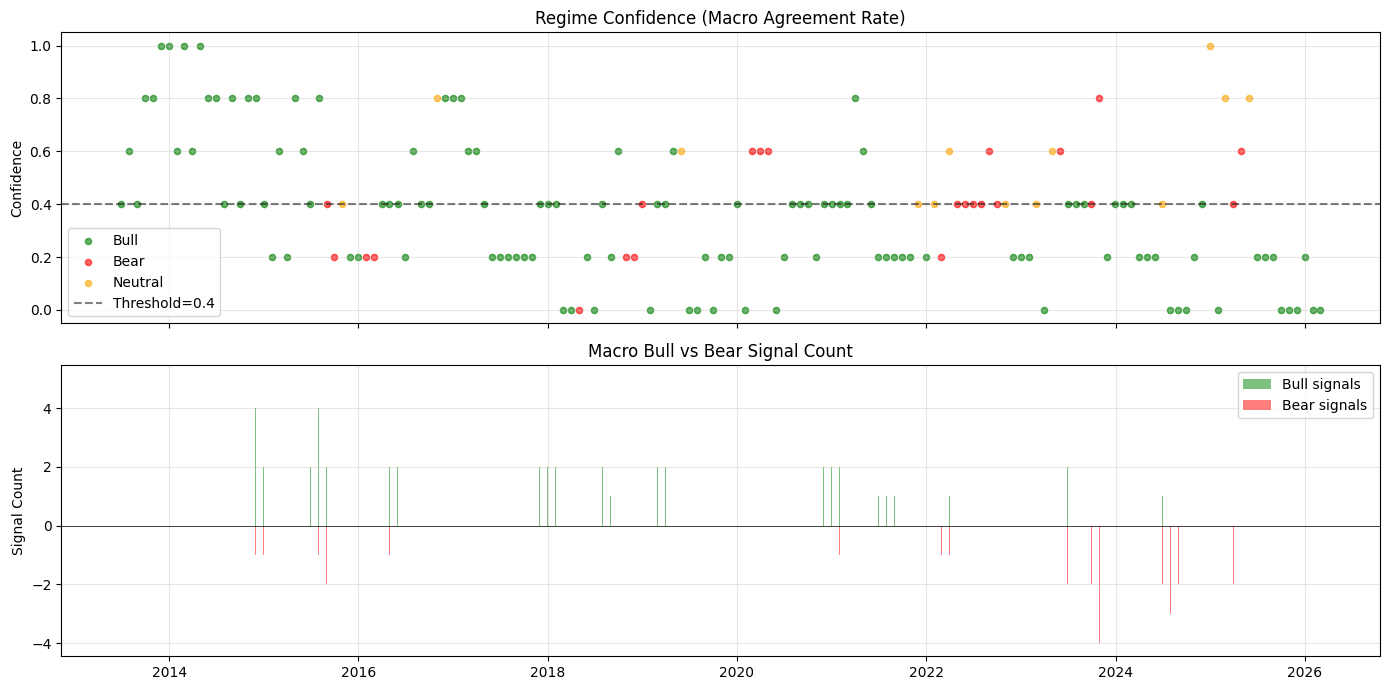

10:27:34 [INFO] 셀 6 완료 — confidence 계산, threshold=0.4
10:27:34 [INFO]   Sub-regime: 6개 유형


In [10]:
# =============================================================================
# 셀 6: 거시변수 3방향 신호 + confidence score
# =============================================================================
# 목적: 원시 거시변수에서 Bull/Neutral/Bear 3방향 신호 생성
#       → v4 레짐과의 동의율로 confidence 계산
#       → sub_regime 라벨 생성
# 산출물: sub_df에 confidence, sub_regime 추가
# =============================================================================

# ── 1. 원시 거시변수 월간 정리 ──
macro = macro_raw.copy()
macro.index = macro.index + pd.offsets.MonthEnd(0)
macro = macro.ffill()  # 발표 시차 NaN 처리

# 백테스트 기간 필터
macro = macro.loc[macro.index >= START_DATE]

# ── 2. 각 변수별 3방향 신호 정의 ──
#
# 임계값 근거:
#   T10Y2Y: 역전(<0)은 100년 검증된 침체 선행지표. >1.5%는 정상 확장
#   T10Y3M: 같은 논리. 단기 금리 기준
#   VIXCLS: CBOE 공식 — <15 낙관, 15~20 보통, >20 불안, >30 공포
#   BAMLH0A0HYM2 (HY 스프레드): 3M 변화 기준. 축소=낙관, 확대=위험
#   UNRATE: 3M 변화 기준. 하락=고용개선, 상승=고용악화
#
# ┌──────────────┬───────────────┬───────────────┬───────────────┐
# │ 변수         │ Bull (+1)     │ Neutral (0)   │ Bear (-1)     │
# ├──────────────┼───────────────┼───────────────┼───────────────┤
# │ T10Y2Y       │ > 1.5%        │ 0 ~ 1.5%      │ < 0 (역전)    │
# │ T10Y3M       │ > 1.5%        │ 0 ~ 1.5%      │ < 0 (역전)    │
# │ VIXCLS       │ < 15          │ 15 ~ 25       │ > 25          │
# │ BAMLH0A0HYM2 │ 3M변화 < -0.3 │ -0.3 ~ +0.3   │ 3M변화 > +0.3 │
# │ UNRATE       │ 3M변화 < -0.2 │ -0.2 ~ +0.2   │ 3M변화 > +0.2 │
# └──────────────┴───────────────┴───────────────┴───────────────┘

signals = pd.DataFrame(index=macro.index)

# T10Y2Y (장단기 금리차)
signals["t10y2y_sig"] = np.where(macro["T10Y2Y"] > 1.5, 1,
                        np.where(macro["T10Y2Y"] < 0, -1, 0))

# T10Y3M (10년-3개월 금리차)
signals["t10y3m_sig"] = np.where(macro["T10Y3M"] > 1.5, 1,
                        np.where(macro["T10Y3M"] < 0, -1, 0))

# VIXCLS (공포지수)
signals["vix_sig"] = np.where(macro["VIXCLS"] < 15, 1,
                     np.where(macro["VIXCLS"] > 25, -1, 0))

# BAMLH0A0HYM2 (신용 스프레드 3M 변화)
baa_chg = macro["BAMLH0A0HYM2"].diff(3)
signals["baa_sig"] = np.where(baa_chg < -0.3, 1,
                     np.where(baa_chg > 0.3, -1, 0))

# UNRATE (실업률 3M 변화)
unrate_chg = macro["UNRATE"].diff(3)
signals["unrate_sig"] = np.where(unrate_chg < -0.2, 1,
                        np.where(unrate_chg > 0.2, -1, 0))

# ── 3. Bull/Bear count ──
sig_cols = ["t10y2y_sig", "t10y3m_sig", "vix_sig", "baa_sig", "unrate_sig"]
signals["macro_bull_count"] = (signals[sig_cols] == 1).sum(axis=1)
signals["macro_bear_count"] = (signals[sig_cols] == -1).sum(axis=1)
signals["macro_neutral_count"] = (signals[sig_cols] == 0).sum(axis=1)

# ── 4. Confidence 계산 ──
# v4 레짐과 거시변수 동의율
# Bull일 때: confidence = bull_count / 5
# Bear일 때: confidence = bear_count / 5
# Neutral일 때: confidence = neutral_count / 5 (어느 쪽도 아닌 게 맞으니까)

common = signals.index.intersection(sub_df.index)
sub_df = sub_df.loc[common].copy()
signals = signals.loc[common]

confidence = pd.Series(0.0, index=common)
for idx in common:
    reg = sub_df.loc[idx, "regime"]
    if reg == "Bull":
        confidence[idx] = signals.loc[idx, "macro_bull_count"] / 5
    elif reg == "Bear":
        confidence[idx] = signals.loc[idx, "macro_bear_count"] / 5
    elif reg == "Neutral":
        confidence[idx] = signals.loc[idx, "macro_neutral_count"] / 5

sub_df["confidence"] = confidence
sub_df["macro_bull_count"] = signals["macro_bull_count"]
sub_df["macro_bear_count"] = signals["macro_bear_count"]

# ── 5. Sub-regime 라벨 ──
# 단순 2단계: confidence > 0.4 → High, else → Low
CONF_THRESHOLD = 0.4
sub_df["conf_level"] = np.where(sub_df["confidence"] > CONF_THRESHOLD, "High", "Low")
sub_df["sub_regime"] = sub_df["regime"] + "_" + sub_df["conf_level"]

# ── 6. 결과 출력 ──
print("=" * 70)
print("거시변수 3방향 신호 분포 (전체 기간)")
print("=" * 70)
for col in sig_cols:
    dist = signals[col].value_counts().sort_index()
    print(f"  {col:15s}: Bear(-1)={dist.get(-1,0):3d}, "
          f"Neutral(0)={dist.get(0,0):3d}, Bull(+1)={dist.get(1,0):3d}")

print("\n" + "=" * 70)
print("Confidence 분포 by Regime")
print("=" * 70)
for reg in ["Bull", "Bear", "Neutral"]:
    vals = sub_df[sub_df["regime"] == reg]["confidence"]
    if len(vals) > 0:
        print(f"  {reg:8s}: mean={vals.mean():.2f}, median={vals.median():.2f}, "
              f"min={vals.min():.2f}, max={vals.max():.2f}")

print("\n" + "=" * 70)
print("Sub-Regime 분포")
print("=" * 70)
print(sub_df["sub_regime"].value_counts().sort_index().to_string())

# ── 7. 시각화: confidence 시계열 ──
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax = axes[0]
colors = {"Bull": "green", "Bear": "red", "Neutral": "orange"}
for reg in ["Bull", "Bear", "Neutral"]:
    mask = sub_df["regime"] == reg
    ax.scatter(sub_df.index[mask], sub_df.loc[mask, "confidence"],
               color=colors[reg], alpha=0.6, s=20, label=reg)
ax.axhline(CONF_THRESHOLD, color="black", linestyle="--", alpha=0.5, label=f"Threshold={CONF_THRESHOLD}")
ax.set_ylabel("Confidence")
ax.set_title("Regime Confidence (Macro Agreement Rate)")
ax.legend()
ax.set_ylim(-0.05, 1.05)

ax2 = axes[1]
ax2.bar(sub_df.index, sub_df["macro_bull_count"], color="green", alpha=0.5, label="Bull signals")
ax2.bar(sub_df.index, -sub_df["macro_bear_count"], color="red", alpha=0.5, label="Bear signals")
ax2.axhline(0, color="black", linewidth=0.5)
ax2.set_ylabel("Signal Count")
ax2.set_title("Macro Bull vs Bear Signal Count")
ax2.legend()

plt.tight_layout()
plt.show()

logger.info(f"셀 6 완료 — confidence 계산, threshold={CONF_THRESHOLD}")
logger.info(f"  Sub-regime: {sub_df['sub_regime'].nunique()}개 유형")

Sub-Regime별 EW 성과
  Sub_Regime  N    CAGR Sharpe   MaxDD Mean_Conf Mean_W12
   Bear_High  7 -36.64%  -1.28 -16.12%      0.63   0.0926
    Bear_Low 16 -29.62%  -1.98 -33.85%      0.30   0.0678
   Bull_High 28  40.18%   4.97  -1.68%      0.75   0.0548
    Bull_Low 89  25.89%   2.09 -11.39%      0.23   0.0634
Neutral_High  7 -12.36%  -0.83  -8.76%      0.74   0.0677
 Neutral_Low  6  19.52%   0.97  -4.73%      0.40   0.0719

High vs Low 차이 (같은 레짐 내)
  Bull_High:  28M, CAGR=40.18%, Sharpe=4.97
  Bull_Low:   89M, CAGR=25.89%, Sharpe=2.09
  → Sharpe 차이: +2.88

  Bear_High:   7M, CAGR=-36.64%, Sharpe=-1.28
  Bear_Low:   16M, CAGR=-29.62%, Sharpe=-1.98
  → Sharpe 차이: +0.70

  Neutral_High:   7M, CAGR=-12.36%, Sharpe=-0.83
  Neutral_Low:    6M, CAGR=19.52%, Sharpe=0.97
  → Sharpe 차이: -1.80

Bull 내부: W-12 × Confidence 2×2
  W12_High × Conf_High:   8M, CAGR=51.71%, Sharpe=4.68
  W12_High × Conf_Low:  41M, CAGR=39.85%, Sharpe=2.73
  W12_Low × Conf_High:  20M, CAGR=35.82%, Sharpe=5.33
  W12_Low × Co

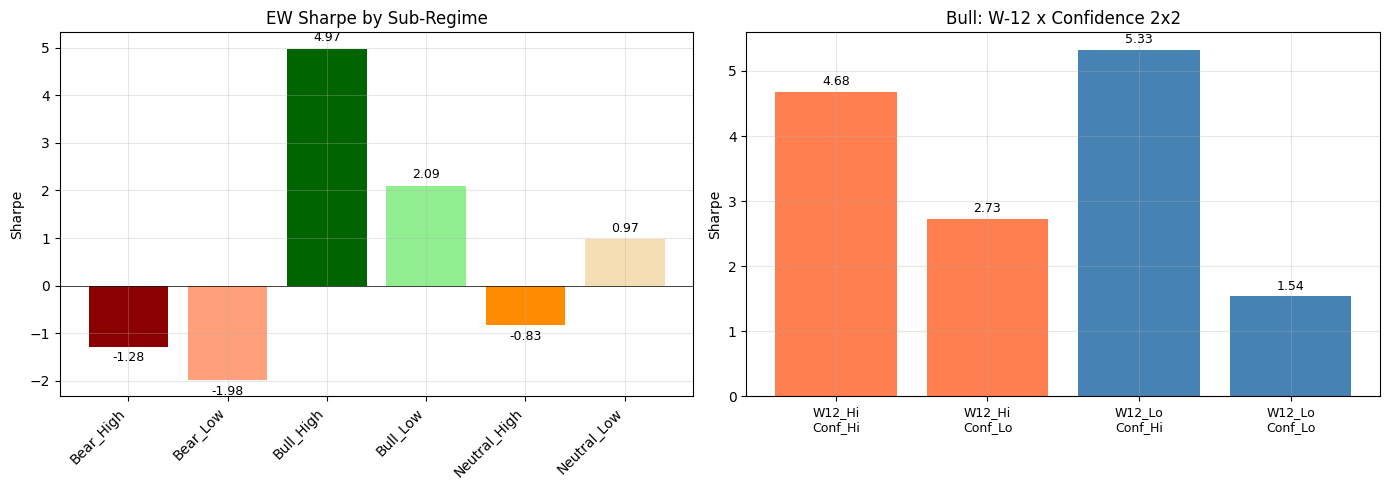

10:31:51 [INFO] 셀 7 완료 — Sub-Regime 성과 분해


In [11]:
# =============================================================================
# 셀 7: Sub-Regime별 EW 성과 분해
# =============================================================================
# 목적: 6개 sub_regime에서 EW 수익률이 실제로 다른지 검증
#       + W-12와 confidence 교차 분석
# 산출물: sub_regime별 성과표, W-12 × confidence 2×2 분석
# =============================================================================

# ── 1. Sub-Regime별 EW 성과 ──
print("=" * 70)
print("Sub-Regime별 EW 성과")
print("=" * 70)

sr_results = []
for sr in sorted(sub_df["sub_regime"].unique()):
    mask = sub_df["sub_regime"] == sr
    ew = sub_df.loc[mask, "ew_ret"]
    if len(ew) < 3:
        continue
    perf = calc_perf(ew, sr)
    sr_results.append({
        "Sub_Regime": sr,
        "N": perf["N"],
        "CAGR": f"{perf['CAGR']:.2%}",
        "Sharpe": f"{perf['Sharpe']:.2f}",
        "MaxDD": f"{perf['MaxDD']:.2%}",
        "Mean_Conf": f"{sub_df.loc[mask, 'confidence'].mean():.2f}",
        "Mean_W12": f"{sub_df.loc[mask, 'w12'].mean():.4f}",
    })

sr_df = pd.DataFrame(sr_results)
print(sr_df.to_string(index=False))

# ── 2. 핵심 비교: High vs Low (레짐 내) ──
print("\n" + "=" * 70)
print("High vs Low 차이 (같은 레짐 내)")
print("=" * 70)

for reg in ["Bull", "Bear", "Neutral"]:
    hi = sub_df[(sub_df["regime"] == reg) & (sub_df["conf_level"] == "High")]["ew_ret"]
    lo = sub_df[(sub_df["regime"] == reg) & (sub_df["conf_level"] == "Low")]["ew_ret"]
    if len(hi) < 3 or len(lo) < 3:
        print(f"  {reg}: 표본 부족 (High={len(hi)}M, Low={len(lo)}M)")
        continue
    p_hi = calc_perf(hi, f"{reg}_High")
    p_lo = calc_perf(lo, f"{reg}_Low")
    diff_sharpe = p_hi["Sharpe"] - p_lo["Sharpe"]
    print(f"  {reg}_High: {p_hi['N']:3d}M, CAGR={p_hi['CAGR']:.2%}, Sharpe={p_hi['Sharpe']:.2f}")
    print(f"  {reg}_Low:  {p_lo['N']:3d}M, CAGR={p_lo['CAGR']:.2%}, Sharpe={p_lo['Sharpe']:.2f}")
    print(f"  → Sharpe 차이: {diff_sharpe:+.2f}")
    print()

# ── 3. W-12 × Confidence 2×2 (Bull 한정) ──
print("=" * 70)
print("Bull 내부: W-12 × Confidence 2×2")
print("=" * 70)

bull = sub_df[sub_df["regime"] == "Bull"].copy()
if len(bull) > 10:
    for w12_lab, w12_mask in [("W12_High", bull["w12_high"] == True),
                               ("W12_Low", bull["w12_high"] == False)]:
        for conf_lab, conf_mask in [("Conf_High", bull["conf_level"] == "High"),
                                     ("Conf_Low", bull["conf_level"] == "Low")]:
            mask = w12_mask & conf_mask
            ew = bull.loc[mask, "ew_ret"]
            if len(ew) < 3:
                print(f"  {w12_lab} × {conf_lab}: 표본 부족 ({len(ew)}M)")
                continue
            perf = calc_perf(ew, f"{w12_lab}_{conf_lab}")
            print(f"  {w12_lab} × {conf_lab}: {perf['N']:3d}M, "
                  f"CAGR={perf['CAGR']:.2%}, Sharpe={perf['Sharpe']:.2f}")

# ── 4. 시각화 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 좌: Sub-regime Sharpe
ax = axes[0]
srs = sorted(sub_df["sub_regime"].unique())
sharpes = []
colors_bar = []
color_map = {"Bull_High": "darkgreen", "Bull_Low": "lightgreen",
             "Bear_High": "darkred", "Bear_Low": "lightsalmon",
             "Neutral_High": "darkorange", "Neutral_Low": "wheat"}
for sr in srs:
    ew = sub_df[sub_df["sub_regime"] == sr]["ew_ret"]
    if len(ew) >= 3:
        s = ew.mean() / ew.std() * np.sqrt(12) if ew.std() > 0 else 0
        sharpes.append(s)
    else:
        sharpes.append(0)
    colors_bar.append(color_map.get(sr, "gray"))

bars = ax.bar(range(len(srs)), sharpes, color=colors_bar)
ax.set_xticks(range(len(srs)))
ax.set_xticklabels(srs, rotation=45, ha="right")
ax.set_ylabel("Sharpe")
ax.set_title("EW Sharpe by Sub-Regime")
ax.axhline(0, color="black", linewidth=0.5)
for bar, s in zip(bars, sharpes):
    ax.text(bar.get_x() + bar.get_width()/2., s + 0.1 * np.sign(s),
            f"{s:.2f}", ha="center", va="bottom" if s >= 0 else "top", fontsize=9)

# 우: Bull 2×2
ax2 = axes[1]
labels_2x2 = []
sharpes_2x2 = []
colors_2x2 = []

if len(bull) > 10:
    for w12_lab, w12_val, c in [("W12_Hi", True, "coral"), ("W12_Lo", False, "steelblue")]:
        for conf_lab, conf_val in [("Conf_Hi", "High"), ("Conf_Lo", "Low")]:
            mask = (bull["w12_high"] == w12_val) & (bull["conf_level"] == conf_val)
            ew = bull.loc[mask, "ew_ret"]
            label = f"{w12_lab}\n{conf_lab}"
            labels_2x2.append(label)
            if len(ew) >= 3:
                s = ew.mean() / ew.std() * np.sqrt(12)
                sharpes_2x2.append(s)
            else:
                sharpes_2x2.append(0)
            colors_2x2.append(c)

    bars2 = ax2.bar(range(len(labels_2x2)), sharpes_2x2, color=colors_2x2)
    ax2.set_xticks(range(len(labels_2x2)))
    ax2.set_xticklabels(labels_2x2, fontsize=9)
    ax2.set_ylabel("Sharpe")
    ax2.set_title("Bull: W-12 x Confidence 2x2")
    ax2.axhline(0, color="black", linewidth=0.5)
    for bar, s in zip(bars2, sharpes_2x2):
        ax2.text(bar.get_x() + bar.get_width()/2., s + 0.1,
                f"{s:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

logger.info("셀 7 완료 — Sub-Regime 성과 분해")

In [12]:
# =============================================================================
# 셀 8: sub_regime.parquet 저장 + 최종 요약
# =============================================================================
# 목적: sub_regime 결과물 저장 + 결론 주석
# 산출물: data/interim/sub_regime.parquet
# =============================================================================

# ── 1. 저장용 DataFrame 구성 ──
out = sub_df[["regime", "w12", "w12_high", "confidence", "conf_level",
              "sub_regime", "macro_bull_count", "macro_bear_count", "ew_ret"]].copy()

# W-12 연율화도 추가
out["w12_ann"] = out["w12"] * np.sqrt(12)

# regime_v4에서 bear_phase 가져오기
rv4_bp = regime_v4.loc[regime_v4.index >= START_DATE, "bear_phase"].copy()
rv4_bp.index = rv4_bp.index + pd.offsets.MonthEnd(0)
common_bp = out.index.intersection(rv4_bp.index)
out.loc[common_bp, "bear_phase"] = rv4_bp.loc[common_bp]

# ── 2. 실전 적용 라벨: Bull만 High/Low, 나머지는 단일 ──
out["sub_regime_final"] = out["regime"]  # 기본값 = v4 그대로
bull_mask = out["regime"] == "Bull"
out.loc[bull_mask, "sub_regime_final"] = out.loc[bull_mask, "sub_regime"]

print("=" * 70)
print("최종 Sub-Regime 분포 (실전 적용)")
print("=" * 70)
print(out["sub_regime_final"].value_counts().sort_index().to_string())

# ── 3. 저장 ──
save_path = INTERIM_DIR / "sub_regime.parquet"
out.to_parquet(save_path)
logger.info(f"저장 완료: {save_path}")
logger.info(f"  Shape: {out.shape}")
logger.info(f"  기간: {out.index[0].date()} ~ {out.index[-1].date()}")
logger.info(f"  컬럼: {list(out.columns)}")

# ── 4. 최종 결론 주석 ──
print("\n" + "=" * 70)
print("03_Sub_Regime 최종 결론")
print("=" * 70)
print("""
[W-12 Cross-Sectional Dispersion]
  - 유효: Bull 내부에서 Sharpe 차이 +0.76 (High 2.97 vs Low 2.21)
  - Bear에서 83%가 High → Bear 감지 보조로도 사용 가능
  - 단독보다 confidence와 교차 시 더 강력

[거시변수 Confidence]
  - Bull에서 강력: High Sharpe=4.97 vs Low Sharpe=2.09 (차이 +2.88)
  - Bear에서 방향 맞지만 표본 부족 (7M vs 16M, 둘 다 음수)
  - Neutral에서 역전 (표본 7/6, 무시)

[2×2 교차 — Bull 내부]
  - 최강: W12_High × Conf_High (8M, Sharpe=4.68, CAGR=51.71%)  ← 표본 적음
  - 안정: W12_Low × Conf_High (20M, Sharpe=5.33, CAGR=35.82%)  ← 안정 강세장
  - 최약: W12_Low × Conf_Low (48M, Sharpe=1.54, CAGR=15.08%)

[실전 적용 결정]
  - Bull → Bull_High / Bull_Low로 분할 (confidence 기준)
  - Bear → 단일 유지 (표본 부족, 나눠도 둘 다 음수)
  - Neutral → 단일 유지 (표본 부족)
  
  ⚠ W-12는 sub_regime 분할에는 미사용 (Bull 내에서 confidence와 중복 효과)
     단, 팩터 강도 조절 보조지표로 06_TheForge에서 별도 활용 가능

[06_TheForge_v2 활용 계획]
  - sub_regime_final 기준으로 가중치 최적화:
    Bull_High:  공격적 (G-1_bull↑, P-7↑)
    Bull_Low:   보수적 (방어 팩터 일부 혼합)
    Bear:       방어 (A-3, P-5, E-5, F-1 필터)
    Neutral:    D-3 + H
  
  - confidence를 연속값으로도 활용 가능:
    weight = base_weight × (0.5 + 0.5 × confidence)
    → High일 때 100%, Low일 때 50~75%
""")

logger.info("셀 8 완료 — 03_Sub_Regime 마무리")

10:35:09 [INFO] 저장 완료: C:\QP2\data\interim\sub_regime.parquet
10:35:09 [INFO]   Shape: (153, 12)
10:35:09 [INFO]   기간: 2013-06-30 ~ 2026-02-28
10:35:09 [INFO]   컬럼: ['regime', 'w12', 'w12_high', 'confidence', 'conf_level', 'sub_regime', 'macro_bull_count', 'macro_bear_count', 'ew_ret', 'w12_ann', 'bear_phase', 'sub_regime_final']
10:35:09 [INFO] 셀 8 완료 — 03_Sub_Regime 마무리


최종 Sub-Regime 분포 (실전 적용)
sub_regime_final
Bear         23
Bull_High    28
Bull_Low     89
Neutral      13

03_Sub_Regime 최종 결론

[W-12 Cross-Sectional Dispersion]
  - 유효: Bull 내부에서 Sharpe 차이 +0.76 (High 2.97 vs Low 2.21)
  - Bear에서 83%가 High → Bear 감지 보조로도 사용 가능
  - 단독보다 confidence와 교차 시 더 강력

[거시변수 Confidence]
  - Bull에서 강력: High Sharpe=4.97 vs Low Sharpe=2.09 (차이 +2.88)
  - Bear에서 방향 맞지만 표본 부족 (7M vs 16M, 둘 다 음수)
  - Neutral에서 역전 (표본 7/6, 무시)

[2×2 교차 — Bull 내부]
  - 최강: W12_High × Conf_High (8M, Sharpe=4.68, CAGR=51.71%)  ← 표본 적음
  - 안정: W12_Low × Conf_High (20M, Sharpe=5.33, CAGR=35.82%)  ← 안정 강세장
  - 최약: W12_Low × Conf_Low (48M, Sharpe=1.54, CAGR=15.08%)

[실전 적용 결정]
  - Bull → Bull_High / Bull_Low로 분할 (confidence 기준)
  - Bear → 단일 유지 (표본 부족, 나눠도 둘 다 음수)
  - Neutral → 단일 유지 (표본 부족)

  ⚠ W-12는 sub_regime 분할에는 미사용 (Bull 내에서 confidence와 중복 효과)
     단, 팩터 강도 조절 보조지표로 06_TheForge에서 별도 활용 가능

[06_TheForge_v2 활용 계획]
  - sub_regime_final 기준으로 가중치 최적화:
    Bull_High:  공격적 (G-1_bull↑, P-7↑)
  

In [ ]:
# =============================================================================
# 셀 9: 03_Sub_Regime IPYNB 요약 (주석셀)
# =============================================================================
#
# 📝 03_Sub_Regime.ipynb 요약
# 작성 시점: 2026-02-20
# 목적: regime_v4의 확신도(confidence) 계산 → sub_regime 생성
#
# =============================================================================
# [노트북 목적]
# =============================================================================
#
#   regime_v4(Bull/Bear/Neutral)에 거시변수 + 시장 구조 지표를 결합하여
#   "확신도"를 부여. 같은 Bull이라도 거시변수가 동의하는 Bull(High)과
#   동의하지 않는 Bull(Low)을 구분 → 팩터 가중치 최적화에 활용.
#
# =============================================================================
# [셀 구조]
# =============================================================================
#
#   셀 1: 설계 + 환경 설정
#   셀 2: 데이터 로드 (regime_v4, ret_1m, px_wide)
#   셀 3: W-12 횡단면 분산 계산 + 시각화
#   셀 4: W-12 × 레짐 교차 분석
#   셀 5: 거시변수 현황 확인 (binary 컬럼 미저장 확인)
#   셀 6: 거시변수 3방향 신호 + confidence score 계산
#   셀 7: Sub-Regime별 EW 성과 분해
#   셀 8: sub_regime.parquet 저장 + 최종 결론
#   셀 9: IPYNB 요약 (이 셀)
#
# =============================================================================
# [핵심 발견]
# =============================================================================
#
#   1. W-12 (Cross-Sectional Dispersion)
#      - Bull 내부: High Sharpe=2.97 vs Low Sharpe=2.21 (차이 +0.76)
#      - Bear에서 83%가 High → Bear 감지 보조 가능
#
#   2. 거시변수 Confidence (5개 변수 동의율)
#      - Bull에서 강력: High Sharpe=4.97 vs Low Sharpe=2.09 (차이 +2.88)
#      - Bear: 방향 맞지만 표본 부족 (7M vs 16M, 둘 다 음수)
#      - Neutral: 역전, 표본 부족 (7/6M) → 무시
#
#   3. Bull 2×2 (W-12 × Confidence)
#      - 최강: W12_High × Conf_High (8M, Sharpe=4.68)  ← 표본 적음
#      - 안정: W12_Low × Conf_High (20M, Sharpe=5.33)  ← 안정 강세장
#      - 최약: W12_Low × Conf_Low (48M, Sharpe=1.54)
#
# =============================================================================
# [실전 적용 결정]
# =============================================================================
#
#   sub_regime_final:
#     Bull_High  (28M) : 거시변수 동의. 공격적 팩터 가중치
#     Bull_Low   (89M) : 거시변수 미동의. 보수적 가중치
#     Bear       (23M) : 단일 유지 (표본 부족)
#     Neutral    (13M) : 단일 유지 (표본 부족)
#
#   W-12: sub_regime 분할에는 미사용 (confidence와 중복)
#         팩터 강도 조절 보조지표로 별도 활용 가능
#
# =============================================================================
# [거시변수 3방향 임계값]
# =============================================================================
#
#   | 변수          | Bull (+1)       | Neutral (0)    | Bear (-1)       |
#   |---------------|-----------------|----------------|-----------------|
#   | T10Y2Y        | > 1.5%          | 0 ~ 1.5%       | < 0 (역전)      |
#   | T10Y3M        | > 1.5%          | 0 ~ 1.5%       | < 0 (역전)      |
#   | VIXCLS        | < 15            | 15 ~ 25        | > 25            |
#   | BAMLH0A0HYM2  | 3M변화 < -0.3   | -0.3 ~ +0.3    | 3M변화 > +0.3   |
#   | UNRATE        | 3M변화 < -0.2   | -0.2 ~ +0.2    | 3M변화 > +0.2   |
#
#   confidence = v4 레짐과 동의하는 변수 수 / 5
#   threshold = 0.4 (> 0.4 → High, else → Low)
#
# =============================================================================
# [산출물]
# =============================================================================
#
#   data/interim/sub_regime.parquet
#     Shape: (153, 12)
#     기간: 2013-06-30 ~ 2026-02-28
#     컬럼: regime, w12, w12_high, confidence, conf_level,
#           sub_regime, macro_bull_count, macro_bear_count,
#           ew_ret, w12_ann, bear_phase, sub_regime_final
#
# =============================================================================
# [변수명 목록]
# =============================================================================
#
#   데이터:
#     regime_v4    : regime_v4.parquet 원본
#     macro_raw    : macro_indicators.parquet (FRED 원시값)
#     ret_1m_wide  : 월간 수익률 wide (503 tickers)
#     ew_ret       : EW 벤치마크 월간 수익률
#     sub_df       : 최종 작업 DataFrame
#
#   W-12:
#     w12          : 월간 횡단면 std
#     w12_high     : > median (bool)
#
#   거시:
#     signals      : 5개 변수 3방향 신호 (-1/0/+1)
#     confidence   : 동의율 (0~1)
#     CONF_THRESHOLD = 0.4
#
#   파라미터:
#     W12_THRESHOLD = "median"
#     CONF_THRESHOLD = 0.4
#     START_DATE = "2013-06-30"
#
# =============================================================================